**Load packages**

In [14]:
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrow
import xlrd
import folium
from branca.colormap import LinearColormap
from branca.colormap import StepColormap
from pathlib import Path

In [16]:
# Set the base directory to the repository root
base_dir = Path().resolve().parent

**Load scraped election results data**

In [128]:
results = pd.read_csv(base_dir / "election-data/election_results.csv")

In [130]:
results.describe()  # 9445 rows

,S.N.,State Code,Constituency Number
count,8902.000000,9445.000000,9445.000000
mean,10.818243,15.955003,17.447009
std,8.252271,8.554023,15.336583
min,1.000000,1.000000,1.000000
25%,5.000000,10.000000,6.000000
50%,9.000000,18.000000,13.000000
75%,15.000000,24.000000,24.000000
max,55.000000,29.000000,80.000000


In [132]:
results.head(30)

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency,State Code,Constituency Number
0,1.0,GUMMA THANUJA RANI,Yuvajana Sramika Rythu Congress Party,471470,5535,477005,40.96,1 - Araku (ST) (Andhra Pradesh),1,1
1,2.0,KOTHAPALLI GEETHA,Bharatiya Janata Party,417113,9312,426425,36.62,1 - Araku (ST) (Andhra Pradesh),1,1
2,3.0,APPALANARASA PACHIPENTA,Communist Party of India (Marxist),119016,4113,123129,10.57,1 - Araku (ST) (Andhra Pradesh),1,1
3,4.0,AVASHYA LAHARI . VARAM,Bahujan Samaj Party,24858,892,25750,2.21,1 - Araku (ST) (Andhra Pradesh),1,1
4,5.0,SAMAREDDY BALAKRISHNA,Independent,9493,42,9535,0.82,1 - Araku (ST) (Andhra Pradesh),1,1
5,6.0,NIMMAKA JAYARAJU,Independent,8798,664,9462,0.81,1 - Araku (ST) (Andhra Pradesh),1,1
6,7.0,ATHIDHI,Independent,8121,15,8136,0.7,1 - Araku (ST) (Andhra Pradesh),1,1
7,8.0,CHANTI BADNAINA,Jai Bharat National Party,7205,47,7252,0.62,1 - Araku (ST) (Andhra Pradesh),1,1
8,9.0,MOTTADAM . RAJABABU,Bharat Adivasi Party,6370,396,6766,0.58,1 - Araku (ST) (Andhra Pradesh),1,1
9,10.0,RANJITH KUMAR PALAKA,Independent,6000,47,6047,0.52,1 - Araku (ST) (Andhra Pradesh),1,1


In [134]:
# Basic cleaning of strings

In [136]:
cols_to_edit = ['Candidate', 'Constituency', 'Party']

In [138]:
for i in cols_to_edit:
    results[i] = results[i].str.strip().str.upper()

In [140]:
results

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency,State Code,Constituency Number
0,1.0,GUMMA THANUJA RANI,YUVAJANA SRAMIKA RYTHU CONGRESS PARTY,471470,5535,477005,40.96,1 - ARAKU (ST) (ANDHRA PRADESH),1,1
1,2.0,KOTHAPALLI GEETHA,BHARATIYA JANATA PARTY,417113,9312,426425,36.62,1 - ARAKU (ST) (ANDHRA PRADESH),1,1
2,3.0,APPALANARASA PACHIPENTA,COMMUNIST PARTY OF INDIA (MARXIST),119016,4113,123129,10.57,1 - ARAKU (ST) (ANDHRA PRADESH),1,1
3,4.0,AVASHYA LAHARI . VARAM,BAHUJAN SAMAJ PARTY,24858,892,25750,2.21,1 - ARAKU (ST) (ANDHRA PRADESH),1,1
4,5.0,SAMAREDDY BALAKRISHNA,INDEPENDENT,9493,42,9535,0.82,1 - ARAKU (ST) (ANDHRA PRADESH),1,1
...,...,...,...,...,...,...,...,...,...,...
9440,1.0,MOHMAD HANEEFA,INDEPENDENT,64443,816,65259,48.15,1 - LADAKH (LADAKH),9,1
9441,2.0,TSERING NAMGYAL,INDIAN NATIONAL CONGRESS,35770,1627,37397,27.59,1 - LADAKH (LADAKH),9,1
9442,3.0,TASHI GYALSON,BHARATIYA JANATA PARTY,31505,451,31956,23.58,1 - LADAKH (LADAKH),9,1
9443,4.0,NOTA,NONE OF THE ABOVE,896,16,912,0.67,1 - LADAKH (LADAKH),9,1


In [142]:
# Separate the Constituency column into Constituency name, Reservation status, and State name
# Also extract Constituency code and verify that it matches Constituency number
# Use regex to extract components
pattern = r"(?P<constituency_code>\d+) - (?P<constituency_name>[^(]+)(?:\((?P<reservation_status>ST|SC)\))? \((?P<state>.+)\)"

In [144]:
# Update the original DataFrame with new columns
results[['Constituency Code', 'Constituency Name', 'Reservation Status', 'State']] = results['Constituency'].str.extract(pattern)

In [146]:
for col in ['Constituency Name', 'State']:
    results[col] = results[col].str.strip()

In [148]:
# Res status has NaNs where it should be Gen
results['Reservation Status'].value_counts(dropna=False)

Reservation Status
NaN    9350
SC       80
ST       15
Name: count, dtype: int64

In [150]:
results['Constituency Name'][results['Reservation Status'].notna()].value_counts(dropna=False)
# okay, lol. Res status is hardly populated in ECI website data. Only 5 are labelled. Drop col

Constituency Name
THIRUPATHI    25
CHITTOOR      21
AMALAPURAM    17
BAPATLA       17
ARAKU         15
Name: count, dtype: int64

In [152]:
print(results['Constituency Code'].dtype)
print(results['Constituency Number'].dtype)
results['Constituency Code'] = results['Constituency Code'].astype(int)
print(results['Constituency Code'].dtype)

object
int64
int64


In [154]:
assert (results['Constituency Code'] == results['Constituency Number']).all()  # True, can drop one of the cols

In [156]:
# Reshape to get Total votes rows as a column, to verify vote shares
# Before doing so, need to convert votes data to numeric

In [158]:
results.columns

Index(['S.N.', 'Candidate', 'Party', 'EVM Votes', 'Postal Votes',
       'Total Votes', '% of Votes', 'Constituency', 'State Code',
       'Constituency Number', 'Constituency Code', 'Constituency Name',
       'Reservation Status', 'State'],
      dtype='object')

In [160]:
vars_to_num = ['EVM Votes', 'Postal Votes', 'Total Votes', '% of Votes']
for col in vars_to_num:
    results[col] = results[col].replace("-", np.nan)
    results[col] = results[col].astype(float)
    print(results[col].dtype)

float64
float64
float64
float64


In [162]:
results[['EVM Votes', 'Postal Votes', 'Total Votes']] = results[['EVM Votes', 'Postal Votes', 'Total Votes']].fillna(0).astype(int)  # Replace NaN with 0 and convert to int
results

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency,State Code,Constituency Number,Constituency Code,Constituency Name,Reservation Status,State
0,1.0,GUMMA THANUJA RANI,YUVAJANA SRAMIKA RYTHU CONGRESS PARTY,471470,5535,477005,40.96,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH
1,2.0,KOTHAPALLI GEETHA,BHARATIYA JANATA PARTY,417113,9312,426425,36.62,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH
2,3.0,APPALANARASA PACHIPENTA,COMMUNIST PARTY OF INDIA (MARXIST),119016,4113,123129,10.57,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH
3,4.0,AVASHYA LAHARI . VARAM,BAHUJAN SAMAJ PARTY,24858,892,25750,2.21,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH
4,5.0,SAMAREDDY BALAKRISHNA,INDEPENDENT,9493,42,9535,0.82,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9440,1.0,MOHMAD HANEEFA,INDEPENDENT,64443,816,65259,48.15,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH
9441,2.0,TSERING NAMGYAL,INDIAN NATIONAL CONGRESS,35770,1627,37397,27.59,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH
9442,3.0,TASHI GYALSON,BHARATIYA JANATA PARTY,31505,451,31956,23.58,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH
9443,4.0,NOTA,NONE OF THE ABOVE,896,16,912,0.67,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH


In [164]:
# Verify total
assert (results["EVM Votes"] + results["Postal Votes"] == results["Total Votes"]).all() # Correct sum?

In [166]:
# Now create Total Votes Cast column

In [168]:
# Step 1: Extract total votes cast for each constituency
# Filter rows where 'Candidate Name' is 'Total' and create a mapping of Constituency Key to Total Votes
total_votes_mapping = results[results['Candidate'] == 'TOTAL'].set_index('Constituency')['Total Votes']

In [170]:
# Step 2: Map the total votes to the main DataFrame
results['Total Votes Cast'] = results['Constituency'].map(total_votes_mapping)

In [172]:
# Step 3: Calculate vote share for each candidate
results['Vote Share (%)'] = (results['Total Votes'] / results['Total Votes Cast']) * 100

In [174]:
# Verify total votes column
assert (results[results['Candidate'] == 'TOTAL']['Total Votes Cast'] == results[results['Candidate'] == 'TOTAL']['Total Votes']).all(), "Mismatch in total votes!"

In [176]:
# After verifying, drop Total rows:
results = results[results['Candidate'] != 'TOTAL'].reset_index(drop=True)
results

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency,State Code,Constituency Number,Constituency Code,Constituency Name,Reservation Status,State,Total Votes Cast,Vote Share (%)
0,1.0,GUMMA THANUJA RANI,YUVAJANA SRAMIKA RYTHU CONGRESS PARTY,471470,5535,477005,40.96,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH,1164445,40.964150
1,2.0,KOTHAPALLI GEETHA,BHARATIYA JANATA PARTY,417113,9312,426425,36.62,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH,1164445,36.620450
2,3.0,APPALANARASA PACHIPENTA,COMMUNIST PARTY OF INDIA (MARXIST),119016,4113,123129,10.57,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH,1164445,10.574050
3,4.0,AVASHYA LAHARI . VARAM,BAHUJAN SAMAJ PARTY,24858,892,25750,2.21,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH,1164445,2.211354
4,5.0,SAMAREDDY BALAKRISHNA,INDEPENDENT,9493,42,9535,0.82,1 - ARAKU (ST) (ANDHRA PRADESH),1,1,1,ARAKU,ST,ANDHRA PRADESH,1164445,0.818845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8897,23.0,NOTA,NONE OF THE ABOVE,4631,14,4645,0.36,5 - JAMMU (JAMMU AND KASHMIR),8,5,5,JAMMU,NaN,JAMMU AND KASHMIR,1302176,0.356711
8898,1.0,MOHMAD HANEEFA,INDEPENDENT,64443,816,65259,48.15,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH,135524,48.153095
8899,2.0,TSERING NAMGYAL,INDIAN NATIONAL CONGRESS,35770,1627,37397,27.59,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH,135524,27.594374
8900,3.0,TASHI GYALSON,BHARATIYA JANATA PARTY,31505,451,31956,23.58,1 - LADAKH (LADAKH),9,1,1,LADAKH,NaN,LADAKH,135524,23.579587


In [178]:
# Compare official and calculated vote shares
results['vote_share_rounded'] = round(results['Vote Share (%)'], 2)
results['vote_share_diff'] = results['vote_share_rounded'] - results['% of Votes']

In [180]:
results['vote_share_diff'].value_counts(dropna=False)  # All 0. great. One NaN is Surat - no share - uncontested.

vote_share_diff
0.0    8901
NaN       1
Name: count, dtype: int64

In [182]:
results[results['vote_share_diff'].isna()]  # Surat

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency,State Code,Constituency Number,Constituency Code,Constituency Name,Reservation Status,State,Total Votes Cast,Vote Share (%),vote_share_rounded,vote_share_diff
1474,1.0,MUKESHKUMAR CHANDRAKAANT DALAL ( UNCONTESTED ),BHARATIYA JANATA PARTY,0,0,0,NaN,24 - SURAT (GUJARAT),6,24,24,SURAT,NaN,GUJARAT,0,NaN,NaN,NaN


In [184]:
# remove unnecessary cols

In [186]:
columns_to_drop = ['EVM Votes', 'Postal Votes', 'Constituency Code', 'Constituency', 
                   'Reservation Status', 'S.N.', '% of Votes', 'State Code', 
                   'Constituency Number', 'vote_share_rounded', 'vote_share_diff'] 
results = results.drop(columns=[col for col in columns_to_drop if col in results.columns])
results

,Candidate,Party,Total Votes,Constituency Name,State,Total Votes Cast,Vote Share (%)
0,GUMMA THANUJA RANI,YUVAJANA SRAMIKA RYTHU CONGRESS PARTY,477005,ARAKU,ANDHRA PRADESH,1164445,40.964150
1,KOTHAPALLI GEETHA,BHARATIYA JANATA PARTY,426425,ARAKU,ANDHRA PRADESH,1164445,36.620450
2,APPALANARASA PACHIPENTA,COMMUNIST PARTY OF INDIA (MARXIST),123129,ARAKU,ANDHRA PRADESH,1164445,10.574050
3,AVASHYA LAHARI . VARAM,BAHUJAN SAMAJ PARTY,25750,ARAKU,ANDHRA PRADESH,1164445,2.211354
4,SAMAREDDY BALAKRISHNA,INDEPENDENT,9535,ARAKU,ANDHRA PRADESH,1164445,0.818845
...,...,...,...,...,...,...,...
8897,NOTA,NONE OF THE ABOVE,4645,JAMMU,JAMMU AND KASHMIR,1302176,0.356711
8898,MOHMAD HANEEFA,INDEPENDENT,65259,LADAKH,LADAKH,135524,48.153095
8899,TSERING NAMGYAL,INDIAN NATIONAL CONGRESS,37397,LADAKH,LADAKH,135524,27.594374
8900,TASHI GYALSON,BHARATIYA JANATA PARTY,31956,LADAKH,LADAKH,135524,23.579587


In [188]:
results.rename(columns={'Constituency Name' : 'Constituency'}, inplace=True)
results

,Candidate,Party,Total Votes,Constituency,State,Total Votes Cast,Vote Share (%)
0,GUMMA THANUJA RANI,YUVAJANA SRAMIKA RYTHU CONGRESS PARTY,477005,ARAKU,ANDHRA PRADESH,1164445,40.964150
1,KOTHAPALLI GEETHA,BHARATIYA JANATA PARTY,426425,ARAKU,ANDHRA PRADESH,1164445,36.620450
2,APPALANARASA PACHIPENTA,COMMUNIST PARTY OF INDIA (MARXIST),123129,ARAKU,ANDHRA PRADESH,1164445,10.574050
3,AVASHYA LAHARI . VARAM,BAHUJAN SAMAJ PARTY,25750,ARAKU,ANDHRA PRADESH,1164445,2.211354
4,SAMAREDDY BALAKRISHNA,INDEPENDENT,9535,ARAKU,ANDHRA PRADESH,1164445,0.818845
...,...,...,...,...,...,...,...
8897,NOTA,NONE OF THE ABOVE,4645,JAMMU,JAMMU AND KASHMIR,1302176,0.356711
8898,MOHMAD HANEEFA,INDEPENDENT,65259,LADAKH,LADAKH,135524,48.153095
8899,TSERING NAMGYAL,INDIAN NATIONAL CONGRESS,37397,LADAKH,LADAKH,135524,27.594374
8900,TASHI GYALSON,BHARATIYA JANATA PARTY,31956,LADAKH,LADAKH,135524,23.579587


***Load map data***  
**Boundaries are unchanged except for Assam**

In [191]:
districts = gpd.read_file(base_dir / "raw-map-data/parliamentary-constituencies/india_pc_2019.shp")

In [192]:
# Replicate 2019 cleaning
districts = districts.drop(["ST_CODE", "PC_CODE"], axis=1)

In [193]:
districts

,ST_NAME,PC_NAME,Res,geometry
0,HIMACHAL PRADESH,KANGRA,GEN,"POLYGON ((76.57659 33.20606, 76.57785 33.20599..."
1,HIMACHAL PRADESH,MANDI,GEN,"POLYGON ((76.79468 33.25638, 76.79541 33.25622..."
2,HIMACHAL PRADESH,HAMIRPUR,GEN,"POLYGON ((76.02031 32.13977, 76.02143 32.13831..."
3,HIMACHAL PRADESH,SHIMLA (SC),SC,"POLYGON ((78.09421 31.41866, 78.09557 31.41853..."
4,PUNJAB,GURDASPUR,GEN,"POLYGON ((75.84332 32.50309, 75.84375 32.50236..."
...,...,...,...,...
538,JHARKHAND,LOHARDAGA (ST),ST,"POLYGON ((84.50551 23.67463, 84.50557 23.67462..."
539,JHARKHAND,PALAMU (SC),SC,"POLYGON ((84.02523 24.62864, 84.02643 24.62833..."
540,JHARKHAND,HAZARIBAGH,GEN,"POLYGON ((85.37836 24.55608, 85.37877 24.55558..."
541,JAMMU & KASHMIR,ANANTNAG,GEN,"POLYGON ((75.27526 34.24881, 75.27739 34.24867..."


In [194]:
districts.rename(columns = {'ST_NAME' : "State", 
                            'PC_NAME' : "Constituency", 
                            'Res' : "Reserved status"}, inplace=True)

In [195]:
districts = districts.sort_values(by = ["State", "Constituency"], ascending=True, ignore_index=True)

In [196]:
# Correct Jalaun Reserved status
# NB different seats might be reserved in 2024 compared to 2019. Need to check
districts.loc[districts["Constituency"] == "JALAUN (SC)", "Reserved status"] = "SC"

In [197]:
# For simplicity and merge-friendliness, remove 'SC' and 'ST' tags from constituency names
# NB specify regex=True, otherwise the replacement will be interpreted literally!
districts["Constituency"] = districts["Constituency"].str.replace(r"\(.*", "", regex=True).str.strip()

In [198]:
# A bit of cleaning of string formatting

In [199]:
for col in ['Constituency', 'State']:
    districts[col] = districts[col].str.strip().str.upper()

In [200]:
districts['Reserved status'] = districts['Reserved status'].replace({'GEN' : 'General'})

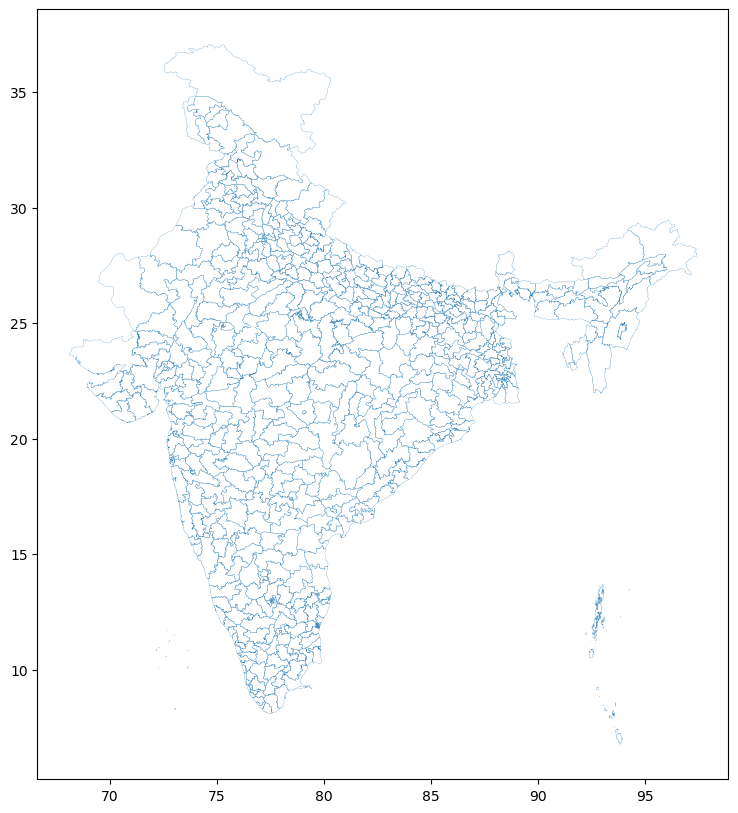

In [201]:
# Plot the map, check that it makes sense
fig, ax = plt.subplots(figsize=(10, 10))
districts.boundary.plot(ax=ax, linewidth=0.15)
plt.show()

In [202]:
districts['Reserved status'].value_counts()

Reserved status
General    411
SC          85
ST          47
Name: count, dtype: int64

In [215]:
# Check and clean state names in both datasets for merge

In [217]:
districts["State"].unique()

array(['ANDAMAN & NICOBAR', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH',
       'ASSAM', 'BIHAR', 'CHANDIGARH', 'CHHATTISGARH',
       'DADRA & NAGAR HAVELI', 'DAMAN & DIU', 'DELHI', 'GOA', 'GUJARAT',
       'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND',
       'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH',
       'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'NAGALAND',
       'ORISSA', 'PUDUCHERRY', 'PUNJAB', 'RAJASTHAN', 'SIKKIM',
       'TAMIL NADU', 'TELANGANA', 'TRIPURA', 'UTTAR PRADESH',
       'UTTARAKHAND', 'WEST BENGAL'], dtype=object)

In [223]:
results["State"].unique()

array(['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'GOA',
       'GUJARAT', 'HARYANA', 'HIMACHAL PRADESH', 'KARNATAKA', 'KERALA',
       'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM',
       'NAGALAND', 'ODISHA', 'PUNJAB', 'RAJASTHAN', 'SIKKIM',
       'TAMIL NADU', 'TRIPURA', 'UTTAR PRADESH', 'WEST BENGAL',
       'CHHATTISGARH', 'JHARKHAND', 'UTTARAKHAND', 'TELANGANA',
       'ANDAMAN & NICOBAR ISLANDS', 'CHANDIGARH',
       'DADRA & NAGAR HAVELI AND DAMAN & DIU', 'NCT OF DELHI',
       'LAKSHADWEEP', 'PUDUCHERRY', 'JAMMU AND KASHMIR', 'LADAKH'],
      dtype=object)

In [225]:
results_corrected_state_names = {'ANDAMAN & NICOBAR ISLANDS' : 'ANDAMAN AND NICOBAR ISLANDS', 
                                 'DADRA & NAGAR HAVELI AND DAMAN & DIU' : 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU',
                                 'NCT OF DELHI' : 'DELHI'}

In [227]:
results["State"] = results["State"].replace(results_corrected_state_names)

In [229]:
districts_corrected_state_names = {'ANDAMAN & NICOBAR' : 'ANDAMAN AND NICOBAR ISLANDS',
                                   'ORISSA' : 'ODISHA',
                                   'DADRA & NAGAR HAVELI' : 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU', 
                                   'DAMAN & DIU' : 'DADRA AND NAGAR HAVELI AND DAMAN AND DIU', 
                                   'JAMMU & KASHMIR' : 'JAMMU AND KASHMIR'}

In [231]:
districts["State"] = districts["State"].replace(districts_corrected_state_names)

In [233]:
# J&K has been split since 2019 election...
# Remove Ladakh from J&K, make it a state

In [235]:
districts[districts['State'] == 'JAMMU AND KASHMIR']

,State,Constituency,Reserved status,geometry
145,JAMMU AND KASHMIR,ANANTNAG,General,"POLYGON ((75.27526 34.24881, 75.27739 34.24867..."
146,JAMMU AND KASHMIR,BARAMULLA,General,"POLYGON ((74.06121 34.81257, 74.09449 34.80118..."
147,JAMMU AND KASHMIR,JAMMU,General,"POLYGON ((74.45574 32.78323, 74.45630 32.78409..."
148,JAMMU AND KASHMIR,LADAKH,General,"POLYGON ((74.73354 37.02003, 74.73551 37.01872..."
149,JAMMU AND KASHMIR,SRINAGAR,General,"POLYGON ((74.94554 34.46247, 74.94985 34.46076..."
150,JAMMU AND KASHMIR,UDHAMPUR,General,"POLYGON ((75.67532 34.22807, 75.67747 34.22782..."


In [237]:
results[results['State'] == 'JAMMU AND KASHMIR']['Constituency'].value_counts()

Constituency
SRINAGAR            25
BARAMULLA           23
JAMMU               23
ANANTNAG-RAJOURI    21
UDHAMPUR            13
Name: count, dtype: int64

In [239]:
districts.loc[((districts['State'] == 'JAMMU AND KASHMIR') & (districts['Constituency'] == 'LADAKH')), 'State'] = 'LADAKH'

In [241]:
merged_2024 = pd.merge(districts, results, how="left", on=["State", "Constituency"])

In [243]:
merged_2024[merged_2024['Party'].isna()]['Constituency'].count()  # x mis-matched constituency names

34

In [245]:
merged_2024[merged_2024['Party'].isna()]['Constituency'].sort_values(ascending=True).unique()

array(['ANANTAPUR', 'ANANTNAG', 'ANDAMAN & NICOBAR', 'ARAMBAG',
       'AUTONOMOUS DISTRICT', 'BAHRAICH', 'BHANDARA-GONDIYA',
       'DADRA & NAGAR HAVELI', 'GADCHIROLI-CHIMUR', 'GAUHATI', 'HARDWAR',
       'HATKANANGLE', 'JAYNAGAR', 'KALIABOR', 'KARAULI -DHOLPUR',
       'KURNOOL', 'MANGALDOI', 'MUMBAI NORTH-CENTRAL',
       'MUMBAI NORTH-EAST', 'MUMBAI NORTH-WEST', 'MUMBAI SOUTH -CENTRAL',
       'NARASARAOPET', 'NORTH EAST DELHI', 'NORTH WEST DELHI', 'NOWGONG',
       'PALAMU', 'PATALIPUTRA', 'PONDICHERRY', 'RATNAGIRI -SINDHUDURG',
       'SREERAMPUR', 'TEZPUR', 'TIRUPATI', 'TONK - SAWAI MADHOPUR',
       'YAVATMAL-WASHIM'], dtype=object)

In [247]:
results["Constituency"].sort_values().unique()

array(['ADILABAD', 'AGRA', 'AHMEDABAD EAST', 'AHMEDABAD WEST',
       'AHMEDNAGAR', 'AJMER', 'AKBARPUR', 'AKOLA', 'ALAPPUZHA', 'ALATHUR',
       'ALIGARH', 'ALIPURDUARS', 'ALLAHABAD', 'ALMORA', 'ALWAR',
       'AMALAPURAM', 'AMBALA', 'AMBEDKAR NAGAR', 'AMETHI', 'AMRAVATI',
       'AMRELI', 'AMRITSAR', 'AMROHA', 'ANAKAPALLE', 'ANAND',
       'ANANDPUR SAHIB', 'ANANTHAPUR', 'ANANTNAG-RAJOURI',
       'ANDAMAN & NICOBAR ISLANDS', 'AONLA', 'ARAKKONAM', 'ARAKU',
       'ARAMBAGH', 'ARANI', 'ARARIA', 'ARRAH', 'ARUNACHAL EAST',
       'ARUNACHAL WEST', 'ASANSOL', 'ASKA', 'ATTINGAL', 'AURANGABAD',
       'AZAMGARH', 'BADAUN', 'BAGALKOT', 'BAGHPAT', 'BAHARAICH',
       'BAHARAMPUR', 'BALAGHAT', 'BALASORE', 'BALLIA', 'BALURGHAT',
       'BANASKANTHA', 'BANDA', 'BANGALORE CENTRAL', 'BANGALORE NORTH',
       'BANGALORE RURAL', 'BANGALORE SOUTH', 'BANGAON', 'BANKA',
       'BANKURA', 'BANSGAON', 'BANSWARA', 'BAPATLA', 'BARABANKI',
       'BARAMATI', 'BARAMULLA', 'BARASAT', 'BARDHAMAN PURBA',
      

In [249]:
results_corrected_constituency_names = {'ANANTHAPUR' :'ANANTAPUR', 
                                        'ANDAMAN & NICOBAR ISLANDS' : 'ANDAMAN AND NICOBAR ISLANDS',
                                        'BAHARAICH' : 'BAHRAICH', 
                                        'BHANDARA GONDIYA' : 'BHANDARA-GONDIYA',
                                        'DADAR & NAGAR HAVELI' : 'DADRA AND NAGAR HAVELI', 
                                        'GADCHIROLI - CHIMUR' : 'GADCHIROLI-CHIMUR',
                                        'HATKANANGALE' : 'HATKANANGLE', 
                                        'JOYNAGAR' : 'JAYNAGAR', 
                                        #'KALIABOR',  # Assam
                                        'KURNOOLU' : 'KURNOOL', 
                                        #'MANGALDOI',  # Assam
                                        'MUMBAI NORTH CENTRAL' : 'MUMBAI NORTH-CENTRAL', 
                                        'MUMBAI NORTH EAST' : 'MUMBAI NORTH-EAST', 
                                        'MUMBAI NORTH WEST' : 'MUMBAI NORTH-WEST', 
                                        'MUMBAI SOUTH CENTRAL' : 'MUMBAI SOUTH-CENTRAL',
                                        'NARSARAOPET' : 'NARASARAOPET', 
                                        'NORTH-EAST DELHI' : 'NORTH EAST DELHI', 
                                        'NORTH-WEST DELHI' : 'NORTH WEST DELHI', 
                                        #'NOWGONG',  # Assam
                                        'PALAMAU' : 'PALAMU', 
                                        'PATLIPUTRA' : 'PATALIPUTRA', 
                                        'RATNAGIRI- SINDHUDURG' : 'RATNAGIRI-SINDHUDURG',
                                        'SRERAMPUR' : 'SREERAMPUR', 
                                        #'TEZPUR',  # Assam
                                        'THIRUPATHI' : 'TIRUPATI',
                                        'YAVATMAL- WASHIM' : 'YAVATMAL-WASHIM'}

In [251]:
districts_corrected_constituency_names = {'ANANTNAG' : 'ANANTNAG-RAJOURI',
                                          'ANDAMAN & NICOBAR' : 'ANDAMAN AND NICOBAR ISLANDS',
                                          'ARAMBAG' : 'ARAMBAGH',
                                          #'AUTONOMOUS DISTRICT' : ,  # Assam
                                          'DADRA & NAGAR HAVELI' : 'DADRA AND NAGAR HAVELI',
                                          'GAUHATI' : 'GUWAHATI', 
                                          'HARDWAR' : 'HARIDWAR', 
                                          'KARAULI -DHOLPUR' : 'KARAULI-DHOLPUR',
                                          'MUMBAI SOUTH -CENTRAL' : 'MUMBAI SOUTH-CENTRAL',
                                          'PONDICHERRY' : 'PUDUCHERRY',
                                          'RATNAGIRI -SINDHUDURG' : 'RATNAGIRI-SINDHUDURG',
                                          'TONK - SAWAI MADHOPUR' : 'TONK-SAWAI MADHOPUR'}

In [253]:
results["Constituency"] = results["Constituency"].replace(results_corrected_constituency_names)

In [255]:
districts["Constituency"] = districts["Constituency"].replace(districts_corrected_constituency_names)

In [257]:
# Merge again
merged_2024 = pd.merge(districts, results, how="left", on=["State","Constituency"])
merged_2024.head(4)

,State,Constituency,Reserved status,geometry,Candidate,Party,Total Votes,Total Votes Cast,Vote Share (%)
0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,General,"MULTIPOLYGON (((93.02419 13.58841, 93.02482 13...",BISHNU PADA RAY,BHARATIYA JANATA PARTY,102436.0,202514.0,50.582182
1,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,General,"MULTIPOLYGON (((93.02419 13.58841, 93.02482 13...",KULDEEP RAI SHARMA,INDIAN NATIONAL CONGRESS,78040.0,202514.0,38.535607
2,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,General,"MULTIPOLYGON (((93.02419 13.58841, 93.02482 13...",MANOJ PAUL,ANDAMAN NICOBAR DEMOCRATIC CONGRESS,8254.0,202514.0,4.075768
3,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,General,"MULTIPOLYGON (((93.02419 13.58841, 93.02482 13...",D AYYAPPAN,COMMUNIST PARTY OF INDIA (MARXIST),6017.0,202514.0,2.971153


In [259]:
merged_2024[merged_2024['Party'].isna()]['Constituency'].sort_values(ascending=True).unique()  # Only Assam!

array(['AUTONOMOUS DISTRICT', 'KALIABOR', 'MANGALDOI', 'NOWGONG',
       'TEZPUR'], dtype=object)

**Create alliance groupings**

In [261]:
# Plus independent O. Paneerselvam in TN - Ramanathapuram
nda_parties_2024 = ['BHARATIYA JANATA PARTY', 'TELUGU DESAM', 
                    'JANATA DAL (UNITED)', 'SHIV SENA', 
                    'PATTALI MAKKAL KATCHI', 'LOK JANSHAKTI PARTY(RAM VILAS)', 
                    'NATIONALIST CONGRESS PARTY', 'BHARATH DHARMA JANA SENA', 
                    'JANATA DAL (SECULAR)', 'TAMIL MAANILA CONGRESS (MOOPANAR)', 
                    'AMMA MAKKAL MUNNETTRA KAZAGAM', 'APNA DAL (SONEYLAL)', 
                    'ASOM GANA PARISHAD', 'JANASENA PARTY', 
                    "NATIONAL PEOPLE'S PARTY", 'RASHTRIYA LOK DAL', 
                    'AJSU PARTY', 'HINDUSTANI AWAM MORCHA (SECULAR)', 
                    'NAGA PEOPLES FRONT', 'NATIONALIST DEMOCRATIC PROGRESSIVE PARTY', 
                    'SIKKIM KRANTIKARI MORCHA', 'RASHTRIYA LOK MORCHA', 
                    'RASHTRIYA SAMAJ PAKSHA', 'SUHELDEV BHARATIYA SAMAJ PARTY', 
                    "UNITED PEOPLE'S PARTY, LIBERAL"]

In [263]:
# check
india_alliance_parties_2024 = ['INDIAN NATIONAL CONGRESS', 'SAMAJWADI PARTY', 
                               'ALL INDIA TRINAMOOL CONGRESS', 'DRAVIDA MUNNETRA KAZHAGAM', 
                               'SHIV SENA (UDDHAV BALASAHEB THACKERAY)', 'NATIONALIST CONGRESS PARTY – SHARADCHANDRA PAWAR', 
                               'RASHTRIYA JANATA DAL', 'AAM AADMI PARTY', 
                               'JHARKHAND MUKTI MORCHA', 'COMMUNIST PARTY OF INDIA (MARXIST)', 
                               'INDIAN UNION MUSLIM LEAGUE', 'JAMMU & KASHMIR NATIONAL CONFERENCE', 
                               'COMMUNIST PARTY OF INDIA', 'KERALA CONGRESS (M)', 
                               'VIDUTHALAI CHIRUTHAIGAL KATCHI', 'REVOLUTIONARY SOCIALIST PARTY', 
                               'MARUMALARCHI DRAVIDA MUNNETRA KAZHAGAM', 'COMMUNIST PARTY OF INDIA (MARXIST–LENINIST) LIBERATION', 
                               'KERALA CONGRESS', 'PEASANTS AND WORKERS PARTY OF INDIA', 
                               'ALL INDIA FORWARD BLOC', 'JAMMU AND KASHMIR PEOPLES DEMOCRATIC PARTY', 
                               'MANITHANEYA MAKKAL KATCHI', 'KONGUNADU MAKKAL DESIA KATCHI', 
                               'RAIJOR DAL', 'ASSAM JATIYA PARISHAD', 
                               'ALL PARTY HILL LEADERS CONFERENCE', 'ANCHALIK GANA MORCHA', 
                               'MAKKAL NEEDHI MAIAM', 'GOA FORWARD PARTY', 
                               'RASHTRIYA LOKTANTRIK PARTY', 'PURBANCHAL LOK PARISHAD', 
                               'JATIYA DAL ASSAM', 'SAMAJWADI GANARAJYA PARTY', 
                               'INDIAN NATIONAL LEAGUE', 'BHARAT ADIVASI PARTY']

In [265]:
results['Party'].sort_values().unique()

array(['AADARSH MITHILA PARTY', 'AADARSH SANGRAM PARTY',
       'AADI BHARAT PARTY', 'AADIM SAMAJ PARTY',
       'AAM AADMI PARIVARTAN PARTY', 'AAM AADMI PARTY',
       'AAM JANMAT PARTY,', 'AAM JANSHAKTI PARTY',
       'AAM JANTA PARTY (INDIA)', 'AAM JANTA PARTY RASHTRIYA',
       'AAM LOK PARTY UNITED',
       'AANAITHINTHIYA JANANAYAKA PATHUKAPPU KAZHAGAM',
       'AAP SABKI APNI PARTY', 'AAPKA GANTANTRA PARTY',
       'AAPKI APNI PARTY (PEOPLES)', 'AAPKI AWAAZ PARTY',
       'AARAKSHAN VIRODHI PARTY', 'AAS PUNJAB PARTY',
       'AAWAMI PICHHADA PARTY', 'AAZAD SAMAJ PARTY (KANSHI RAM)',
       'ABHAY SAMAJ PARTY', 'ABHINAV BHARAT JANSEVA PAKSH',
       'ABHINAV RAJASTHAN PARTY', 'ABUA JHARKHAND PARTY',
       'ADARSH JANKALYAN DAL', 'ADARSH JANTA PARTY,',
       'ADARSH NYAY RAKSHAK PARTY', 'ADARSH SAMAJ PARTY',
       'ADARSHWAADI CONGRESS PARTY', 'ADIM BHARTIYA DAL',
       'AHIMSA SOCIALIST PARTY', 'AHINSA SAMAJ PARTY',
       'AIHRA NATIONAL PARTY', 'AIM POLITICAL PARTY', 'AJSU 

**Maps**

***BJP 2024***

In [269]:
results_2024_bjp = results[results["Party"] == "BHARATIYA JANATA PARTY"].copy()

In [271]:
merged_2024_bjp = pd.merge(districts, results_2024_bjp, on=["State", "Constituency"], how="left")

In [273]:
merged_2024_bjp

,State,Constituency,Reserved status,geometry,Candidate,Party,Total Votes,Total Votes Cast,Vote Share (%)
0,ANDAMAN AND NICOBAR ISLANDS,ANDAMAN AND NICOBAR ISLANDS,General,"MULTIPOLYGON (((93.02419 13.58841, 93.02482 13...",BISHNU PADA RAY,BHARATIYA JANATA PARTY,102436.0,202514.0,50.582182
1,ANDHRA PRADESH,AMALAPURAM,SC,"MULTIPOLYGON (((81.79186 16.92490, 81.79327 16...",NaN,NaN,NaN,NaN,NaN
2,ANDHRA PRADESH,ANAKAPALLE,General,"POLYGON ((83.01993 18.11363, 83.02175 18.11361...",C.M.RAMESH,BHARATIYA JANATA PARTY,762069.0,1325332.0,57.500234
3,ANDHRA PRADESH,ANANTAPUR,General,"POLYGON ((77.66529 15.23324, 77.66569 15.23295...",NaN,NaN,NaN,NaN,NaN
4,ANDHRA PRADESH,ARAKU,ST,"POLYGON ((83.63763 19.15319, 83.63750 19.15295...",KOTHAPALLI GEETHA,BHARATIYA JANATA PARTY,426425.0,1164445.0,36.620450
...,...,...,...,...,...,...,...,...,...
538,WEST BENGAL,RAIGANJ,General,"POLYGON ((88.28875 26.35126, 88.28917 26.35076...",KARTICK CHANDRA PAUL,BHARATIYA JANATA PARTY,560897.0,1368471.0,40.987131
539,WEST BENGAL,RANAGHAT,SC,"POLYGON ((88.48653 23.53932, 88.48834 23.53850...",JAGANNATH SARKAR,BHARATIYA JANATA PARTY,782396.0,1540632.0,50.784094
540,WEST BENGAL,SREERAMPUR,General,"POLYGON ((88.35380 22.85111, 88.35376 22.84670...",KABIR SHANKAR BOSE,BHARATIYA JANATA PARTY,499140.0,1476532.0,33.804889
541,WEST BENGAL,TAMLUK,General,"POLYGON ((87.84897 22.51125, 87.84935 22.51123...",ABHIJIT GANGOPADHYAY,BHARATIYA JANATA PARTY,765584.0,1577319.0,48.537043


In [277]:
merged_2024_bjp['Party'].value_counts(dropna=False)  # 436 BJP. Should be 441, probably Assam

Party
BHARATIYA JANATA PARTY    436
NaN                       107
Name: count, dtype: int64

In [283]:
# Create and save geo BJP 2024 dataset
geo_bjp_2024 = gpd.GeoDataFrame(merged_2024_bjp, geometry='geometry')
geo_bjp_2024.to_parquet("geo_bjp_2024.parquet")

UnsupportedGEOSVersionError: The "iso" option requires at least GEOS 3.10.0

***Initial static plot of BJP 2024 results***

In [ ]:
# Define the colormap (from lighter to darker orange)
cmap = mcolors.LinearSegmentedColormap.from_list('orange_cmap', ['#FFEB99', '#FF6600'])

# Separate the data based on vote share
bjp_candidates = geo_bjp_2024[geo_bjp_2024["Vote Share (%)"] > 0]
nda_candidates = geo_bjp_2024[geo_bjp_2024["Vote Share (%)"].isna()]

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot districts with BJP candidates
bjp_candidates.plot(column="Vote Share (%)", cmap=cmap, linewidth=0.1, edgecolor="gray", ax=ax, legend=True)

# Plot districts with no BJP presence in gray
nda_candidates.plot(color="#D3D3D3", linewidth=0.05, edgecolor="gray", ax=ax)

# Add a title
ax.set_title("Constituency-wise BJP Vote Share in 2024 (%)", fontsize=16)

# Remove axis for better visualization
ax.axis('off')

# Show the plot
plt.show()

**Interactive 2024 map for BJP**

In [ ]:
# Define the colors and corresponding thresholds
colors = ['#FFEB99', '#FFC266', '#FF9933', '#FF6600']  # Light to dark orange
thresholds = [0, 10, 30, 50, 100]  # Ranges for Vote Share (%)

# Create a StepColormap
colormap = StepColormap(
    colors=colors,
    vmin=0,
    vmax=100,
    index=thresholds,
    caption="BJP Vote Share in 2024"
)

# Initialize the map
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5, tiles=None)

# Add GeoJSON data
geojson = folium.GeoJson(
    geo_bjp_2024.to_json(),
    style_function=lambda feature: {
        'fillColor': (
            '#D3D3D3' if feature['properties']['Vote Share (%)'] in [None, ''] 
            else colormap(float(feature['properties']['Vote Share (%)']))
        ),
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['State', 'Constituency', 'Vote Share (%)'],
        aliases=['State:', 'Constituency:', 'Vote share (%):'],
        localize=True
    )
).add_to(m)

# Fit the map to the bounds of the GeoDataFrame
bounds = geo_bjp_2024.total_bounds  # [minx, miny, maxx, maxy]
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

# Add the colormap to the map
colormap.add_to(m)

# Inject CSS for a white background
from folium.plugins import FloatImage

css = """
<style>
    .leaflet-container {
        background: #FFFFFF !important;
    }
</style>
"""
folium.Html(css, script=True).add_to(m)

# Save and display the map
m.save("bjp_vote_share_map_2024.html")
m

**Congress maps**

In [ ]:
results_2024_congress = results[results["Party"] == "INDIAN NATIONAL CONGRESS"].copy()

In [ ]:
results_2024_congress

In [ ]:
merged_2024_congress = districts.merge(results_2024_congress, on=["State", "Constituency"], how="left")

In [ ]:
merged_2024_congress['Party'].value_counts(dropna=False)  # 323 INC. Should be 326. Probably Assam

In [ ]:
geo_congress_2024 = gpd.GeoDataFrame(merged_2024_congress, geometry='geometry')

***Interactive 2024 Congress map***

In [ ]:
# Define the colors and corresponding thresholds
colors = ['#cff0fc', '#9cd6f5', '#65b9eb', '#0384fc']  # Light to dark blue
thresholds = [0, 10, 30, 50, 100]  # Ranges for Vote Share (%)

# Create a StepColormap
colormap = StepColormap(
    colors=colors,
    vmin=0,
    vmax=100,
    index=thresholds,
    caption="Congress Vote Share in 2024"
)

# Initialize the map
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5, tiles=None)

# Add GeoJSON data
geojson = folium.GeoJson(
    geo_congress_2024.to_json(),
    style_function=lambda feature: {
        'fillColor': (
            '#D3D3D3' if feature['properties']['Vote Share (%)'] in [None, ''] 
            else colormap(float(feature['properties']['Vote Share (%)']))
        ),
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['State', 'Constituency', 'Vote Share (%)'],
        aliases=['State:', 'Constituency:', 'Vote share (%):'],
        localize=True
    )
).add_to(m)

# Fit the map to the bounds of the GeoDataFrame
bounds = geo_congress_2024.total_bounds  # [minx, miny, maxx, maxy]
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

# Add the colormap to the map
colormap.add_to(m)

# Inject CSS for a white background
from folium.plugins import FloatImage

css = """
<style>
    .leaflet-container {
        background: #FFFFFF !important;
    }
</style>
"""
folium.Html(css, script=True).add_to(m)

# Save and display the map
m.save("congress_vote_share_map_2024.html")
m

In [ ]:
# Save Congress results dataset
geo_congress_2024.to_file("geo_congress_2024.geojson", driver="GeoJSON")

***NDA map***

In [ ]:
nda_results_2024 = results.copy()
nda_results_2024['nda_tag'] = ((nda_results_2024["Party"].isin(nda_parties_2024)) | 
                              ((nda_results_2024["Constituency"] == "RAMANATHAPURAM") & (nda_results_2024["Candidate"] == "PANNEERSELVAM O S/O OTTAKARATHEVAR")))

In [ ]:
nda_results_2024 = nda_results_2024[nda_results_2024['nda_tag'] == True]

In [ ]:
nda_results_2024.head()

In [ ]:
nda_results_2024['Party'].value_counts(dropna=False)

In [ ]:
nda_results_2024[nda_results_2024.duplicated(subset=["Constituency", "State"], keep=False)]  
# Lots of Rashtriya Samaj Paksha; some National People's Party, some AJSU, one BJP 

In [ ]:
# Check RSP
results[results['Party'] == 'RASHTRIYA SAMAJ PAKSHA']  
# 18 seats, of which only 1 (in Maha) was part of NDA
# In the other 17 seats they must have had friendly contests and got <1% vote share

In [ ]:
# Drop the non-NDA Rashtriya Samaj Paksha candidates
nda_results_2024 = nda_results_2024[~((nda_results_2024["Party"] == "RASHTRIYA SAMAJ PAKSHA") & 
                                      (nda_results_2024["State"] != "MAHARASHTRA"))]

In [ ]:
# Now check AJSU
results[results['Party'] == 'AJSU PARTY']  
# 3 seats, of which only 1 (Giridih in Jharkhand) was part of NDA
# In the other 2 seats they must have had friendly contests and got <0.5% vote share

In [ ]:
# Drop the non-NDA AJSU candidates
nda_results_2024 = nda_results_2024[~((nda_results_2024["Party"] == "AJSU PARTY") & 
                                      (nda_results_2024["State"] != "JHARKHAND"))]

In [ ]:
# Now check National People's Party
results[results['Party'] == "NATIONAL PEOPLE'S PARTY"]  
# 3 seats, of which 2 (both in Meghalaya) were part of NDA
# The other seat is in Mumbai so probably a totally different one-seat party

In [ ]:
# Drop NATIONAL PEOPLE'S PARTY from Mumbai North-East
nda_results_2024 = nda_results_2024[~((nda_results_2024["Party"] == "NATIONAL PEOPLE'S PARTY") & 
                                      (nda_results_2024["State"] != "MEGHALAYA"))]

In [ ]:
# In Sikkim's lone seat, SKM and BJP are both part of NDA and both contested
# But SKM got ~8x BJP's votes and was the main NDA contestant
# So I'm going to drop BJP Sikkim from NDA dataset
nda_results_2024 = nda_results_2024[~((nda_results_2024["Party"] == "BHARATIYA JANATA PARTY") & 
                                      (nda_results_2024["State"] == "SIKKIM"))]

In [ ]:
nda_results_2024

In [ ]:
geo_nda_2024 = pd.merge(districts, nda_results_2024, on=["State", "Constituency"], how="left")

In [ ]:
geo_nda_2024 = gpd.GeoDataFrame(geo_nda_2024, geometry='geometry')

In [ ]:
geo_nda_2024

In [ ]:
# Basic map, NDA
# No NDA candidates - Kashmir Valley; plus Assam will be dealt with later
nda_candidates = geo_nda_2024[geo_nda_2024["Vote Share (%)"].notna()]
no_nda_candidates = geo_nda_2024[geo_nda_2024["Vote Share (%)"].isna()]

# Define the colormap (from lighter to darker orange)
cmap = mcolors.LinearSegmentedColormap.from_list('orange_cmap', ['#FFEB99', '#FF6600'])

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
nda_candidates.plot(column="Vote Share (%)", cmap=cmap, linewidth=0.1, edgecolor="gray", ax=ax, legend=True)
no_nda_candidates.plot(color="#D3D3D3", linewidth=0.05, edgecolor="gray", ax=ax)

# Add a title
ax.set_title("Constituency-wise NDA Vote Share in 2024 (%)", fontsize=16)

# Remove axis for better visualization
ax.axis('off')

# Show the plot
plt.show()

***Interactive 2024 NDA map***

In [ ]:
# Define the colors and corresponding thresholds
colors = ['#FFEB99', '#FFC266', '#FF9933', '#FF6600']  # Light to dark orange
thresholds = [0, 10, 30, 50, 100]  # Ranges for Vote Share (%)

# Create a StepColormap
colormap = StepColormap(
    colors=colors,
    vmin=0,
    vmax=100,
    index=thresholds,
    caption="NDA Vote Share in 2024"
)

# Initialize the map
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5, tiles=None)

# Add GeoJSON data
geojson = folium.GeoJson(
    geo_nda_2024.to_json(),
    style_function=lambda feature: {
        'fillColor': (
            '#D3D3D3' if feature['properties']['Vote Share (%)'] in [None, ''] 
            else colormap(float(feature['properties']['Vote Share (%)']))
        ),
        'color': 'black',
        'weight': 0.5,
        'fillOpacity': 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['State', 'Constituency', 'Vote Share (%)'],
        aliases=['State:', 'Constituency:', 'Vote share (%):'],
        localize=True
    )
).add_to(m)

# Fit the map to the bounds of the GeoDataFrame
bounds = geo_nda_2024.total_bounds  # [minx, miny, maxx, maxy]
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

# Add the colormap to the map
colormap.add_to(m)

# Inject CSS for a white background
from folium.plugins import FloatImage

css = """
<style>
    .leaflet-container {
        background: #FFFFFF !important;
    }
</style>
"""
folium.Html(css, script=True).add_to(m)

# Save and display the map
m.save("nda_vote_share_map_2024.html")
m

In [ ]:
# Save NDA results dataset
geo_nda_2024.to_file("geo_nda_2024.geojson", driver="GeoJSON")